### Simulador de ataques clásicos y modernos

Este notebook contiene el proyecto final de la microcredencial "Criptografía y Seguridad Digital" de la Universidad de La Laguna. El objetivo es simular diversos ataques criptográficos, tanto clásicos como modernos, utilizando Python. Por ello, se han implementado los siguientes ataques:
- Análisis de frecuencia  
- IC + Kasiski  
- Padding oracle (simulado)  
- Ataque por nonce reutilizado  
- Visualizaciones usando matplotlib o Streamlit

---

# 1. Cifrados Clásicos

In [2]:
message: str = "ESTE ES UN MENSAJE SECRETO"

Antes de comenzar definiremos el mensaje que vamos a cifrar en el resto de secciones:

## Cifrado César

En esta sección, nos centraremos en el cifrado César, un método de cifrado por sustitución en el que cada letra del texto original se reemplaza por otra letra que se encuentra un número fijo de posiciones más adelante en el alfabeto. Implementaremos tanto el cifrado como el descifrado, y luego simularemos un ataque de análisis de frecuencia para intentar recuperar el mensaje original sin conocer la clave.

### Cifrado

Para el cifrado, definiremos una función que tome un texto y un desplazamiento (clave) como argumentos y devuelva el texto cifrado. El desplazamiento indicará cuántas posiciones se moverán las letras en el alfabeto.

In [3]:
def cesar_encrypt(text: str, key: int) -> str:
    """Cifra un texto utilizando el cifrado César.

    Args:
        text (str): El texto que se desea cifrar.
        key (int): El número de posiciones que se desean desplazar las letras en el cifrado.

    Returns:
        str: El texto cifrado, con las letras desplazadas según el valor de la clave.
    """
    START = ord("A")
    ALPHABET_SIZE = 26
    result: str = ""
    for char in text.upper():
        if char.isalpha():
            result += chr((ord(char) - START + key) % ALPHABET_SIZE + START)
        else:
            result += char
    return result

Probamos a cifrar un mensaje utilizando una clave específica, y mostramos el resultado cifrado.

In [4]:
key: int = 4
ciphertext: str = cesar_encrypt(message, key)
print(f"Mensaje original: {message}")
print(f"Mensaje cifrado: {ciphertext}")

Mensaje original: ESTE ES UN MENSAJE SECRETO
Mensaje cifrado: IWXI IW YR QIRWENI WIGVIXS


### Descifrado

En cuanto al descifrado, crearemos una función que reciba un texto cifrado y un desplazamiento, y devuelva el texto original. Esta función simplemente realizará el proceso inverso al cifrado, moviendo las letras hacia atrás en el alfabeto.

In [5]:
def cesar_decrypt(cipher: str, key: int) -> str:
    """Descifra un texto cifrado utilizando el cifrado César.

    Args:
        cipher (str): El texto cifrado que se desea descifrar.
        key (int): El número de posiciones que se han desplazado las letras en el cifrado.

    Returns:
        str: El texto descifrado, con las letras desplazadas de vuelta a su posición original.
    """
    START = ord("A")
    ALPHABET_SIZE = 26
    result: str = ""
    for char in cipher.upper():
        if char.isalpha():
            result += chr((ord(char) - START - key) % ALPHABET_SIZE + START)
        else:
            result += char
    return result

Para probar el correcto funcionamiento de ambas funciones, desciframos el mensaje cifrado anteriormente utilizando la misma clave. De esta manera, podemos verificar que el mensaje original se recupera correctamente.

In [6]:
decrypted_message: str = cesar_decrypt(ciphertext, key)
print(f"Mensaje descifrado: {decrypted_message}")

Mensaje descifrado: ESTE ES UN MENSAJE SECRETO


Podríamos sintetizar esto en un único método que reciba un mensaje, una clave y una operación (cifrar o descifrar)

In [7]:
def caesar_cipher(text: str, key: int, decrypt: bool) -> str:
    """Cifra o descifra un texto utilizando el cifrado César.

    Args:
        text (str): El texto a cifrar o descifrar.
        key (int): La clave de cifrado (número de posiciones a desplazar).
        decrypt (bool): Indica si se desea descifrar (True) o cifrar (False).

    Returns:
        str: El texto cifrado o descifrado.
    """
    START = ord("A")
    ALPHABET_SIZE = 26
    result: str = ""
    if decrypt:
        key = -key
    for char in text.upper():
        if char.isalpha():
            result += chr((ord(char) - START + key) % ALPHABET_SIZE + START)
        else:
            result += char
    return result

Lo probamos igual que antes, cifrando y descifrando el mensaje para verificar que el resultado es correcto.

In [8]:
ciphertext: str = caesar_cipher(message, key, decrypt=False)
print(f"Mensaje original: {message}")
print(f"Mensaje cifrado: {ciphertext}")
decrypted_message: str = caesar_cipher(ciphertext, key, decrypt=True)
print(f"Mensaje descifrado: {decrypted_message}")

Mensaje original: ESTE ES UN MENSAJE SECRETO
Mensaje cifrado: IWXI IW YR QIRWENI WIGVIXS
Mensaje descifrado: ESTE ES UN MENSAJE SECRETO


### Ataque por fuerza bruta

Para un cifrado como el César, donde el espacio de claves es pequeño (26 posibles desplazamientos), un ataque por fuerza bruta es factible. Esto implica probar todas las posibles claves hasta encontrar el mensaje original. Implementaremos este ataque y mostraremos los resultados para cada posible clave, lo que nos permitirá identificar el mensaje correcto basándonos en la legibilidad del texto resultante.

In [9]:
for possible_key in range(26):
	decrypted_attempt: str = caesar_cipher(ciphertext, possible_key, decrypt=True)
	print(f"Clave: {possible_key}, Mensaje descifrado: {decrypted_attempt}")

Clave: 0, Mensaje descifrado: IWXI IW YR QIRWENI WIGVIXS
Clave: 1, Mensaje descifrado: HVWH HV XQ PHQVDMH VHFUHWR
Clave: 2, Mensaje descifrado: GUVG GU WP OGPUCLG UGETGVQ
Clave: 3, Mensaje descifrado: FTUF FT VO NFOTBKF TFDSFUP
Clave: 4, Mensaje descifrado: ESTE ES UN MENSAJE SECRETO
Clave: 5, Mensaje descifrado: DRSD DR TM LDMRZID RDBQDSN
Clave: 6, Mensaje descifrado: CQRC CQ SL KCLQYHC QCAPCRM
Clave: 7, Mensaje descifrado: BPQB BP RK JBKPXGB PBZOBQL
Clave: 8, Mensaje descifrado: AOPA AO QJ IAJOWFA OAYNAPK
Clave: 9, Mensaje descifrado: ZNOZ ZN PI HZINVEZ NZXMZOJ
Clave: 10, Mensaje descifrado: YMNY YM OH GYHMUDY MYWLYNI
Clave: 11, Mensaje descifrado: XLMX XL NG FXGLTCX LXVKXMH
Clave: 12, Mensaje descifrado: WKLW WK MF EWFKSBW KWUJWLG
Clave: 13, Mensaje descifrado: VJKV VJ LE DVEJRAV JVTIVKF
Clave: 14, Mensaje descifrado: UIJU UI KD CUDIQZU IUSHUJE
Clave: 15, Mensaje descifrado: THIT TH JC BTCHPYT HTRGTID
Clave: 16, Mensaje descifrado: SGHS SG IB ASBGOXS GSQFSHC
Clave: 17, Mensaje desci

Podemos ver como para la clave elegida, el mensaje descifrado es legible y coincide con el mensaje original, mientras que para las demás claves el resultado es un texto sin sentido.

### Ataque por Análisis de Frecuencia

Como sabemos que en el idioma español, ciertas letras aparecen con mayor frecuencia que otras (por ejemplo, la letra 'E' es la más común), podemos utilizar esta información para intentar recuperar la clave de cifrado. Implementaremos un ataque de análisis de frecuencia que cuente la frecuencia de cada letra en el texto cifrado y compare estas frecuencias con las frecuencias típicas del idioma español para hacer una suposición informada sobre el desplazamiento utilizado en el cifrado.

In [10]:
from collections import Counter

def cesar_get_shift(cipher: str) -> int:
    """Determina el desplazamiento utilizado en un cifrado César analizando la
    frecuencia de las letras en el texto cifrado. Asume que la letra más frecuente en el
    texto cifrado corresponde a la letra 'E' en el idioma español, que es la letra más 
    común.

    Args:
        cipher (str): El texto cifrado.

    Returns:
        int: El desplazamiento utilizado en el cifrado César.
    """
    Counter(cipher)
    most_common = Counter(cipher).most_common(1)[0][0]
    return (ord(most_common) - ord("E")) % 26

Así que si el texto es lo suficientemente largo, es muy probable que la letra más frecuente en el texto cifrado corresponda a la letra 'E' del idioma español. A partir de esta suposición, como podemos ver.

In [40]:
print(f"Desplazamiento estimado: {cesar_get_shift(ciphertext)}")
print(f"Mensaje descifrado con desplazamiento estimado: {caesar_cipher(ciphertext, cesar_get_shift(ciphertext), decrypt=True)}")

Desplazamiento estimado: 4
Mensaje descifrado con desplazamiento estimado: EKXE EK UA FEAKGME KEROEXD


## Cifrado Monoalfabético

César es un caso particular de cifrado monoalfabético, donde cada letra se sustituye por otra letra fija. En esta sección, implementaremos un cifrado monoalfabético más general, donde cada letra del alfabeto puede ser reemplazada por cualquier otra letra. Esto aumenta significativamente el espacio de claves, haciendo que un ataque por fuerza bruta sea impracticable.

Comenzamos importando la biblioteca `string` para obtener el alfabeto y luego definimos la función de cifrado monoalfabético. Esta función tomará un mensaje y una clave (que es una permutación del alfabeto) y devolverá el mensaje cifrado. Para poder elegir una permutación aleatoria del alfabeto, utilizaremos la función `random.shuffle` de la biblioteca `random`.

In [ ]:
import string
import random

ALPHABET = string.ascii_uppercase

def get_random_mono_key() -> str:
    """Genera una clave aleatoria válida para cifrado monoalfabético (una 
    permutación del alfabeto)."""
    chars = list(ALPHABET)
    random.shuffle(chars)
    return "".join(chars)

### Cifrado

En este caso ciframos un mensaje utilizando una clave que es una permutación aleatoria del alfabeto. Esto nos permite pasar de las 26 posibles claves del cifrado César a 26! posibles claves, haciendo que un ataque por fuerza bruta sea completamente inviable.  

In [13]:
def mono_encrypt(message: str, key: str) -> str:
    """Cifra un mensaje utilizando un cifrado monoalfabético con la clave dada.

    Args:
        message (str): El mensaje a cifrar.
        key (str): Una permutación del alfabeto que representa la clave de cifrado.

    Returns:
        str: El mensaje cifrado.
    """
    mapping = dict(zip(ALPHABET, key))
    return "".join(mapping.get(c, c) for c in message.upper())

Probamos a cifrar un mensaje utilizando una clave generada aleatoriamente, y mostramos el resultado cifrado.

In [ ]:
key = get_random_mono_key()
print(f"Clave: {key}")
ciphertext = mono_encrypt(message, key)
print(f"Cifrado: {ciphertext}")

Clave: KCVLIFWUTQRZJEHDGSOBYXMNPA
Cifrado: IOBI IO YE JIEOKQI OIVSIBH


### Descifrado

Para el descifrado, implementaremos una función que reciba un mensaje cifrado y la clave utilizada para el cifrado (la permutación elegida), y devuelva el mensaje original. Esta función realizará el proceso inverso al cifrado, utilizando la clave para mapear cada letra cifrada de vuelta a su letra original.

In [15]:
def mono_decrypt(cipher: str, key: str) -> str:
    """Descifra un mensaje cifrado utilizando un cifrado monoalfabético con la clave dada.

    Args:
        cipher (str): El mensaje cifrado que se desea descifrar.
        key (str): Una permutación del alfabeto que representa la clave de cifrado 
        utilizada para cifrar el mensaje.

    Returns:
        str: El mensaje descifrado.
    """
    inverse_mapping = dict(zip(key, ALPHABET))
    return "".join(inverse_mapping.get(c, c) for c in cipher.upper())

Comprobamos el correcto funcionamiento del cifrado y descifrado, asegurándonos de que el mensaje original se recupera correctamente a partir del mensaje cifrado utilizando la misma clave.

In [16]:
print(f"Descifrado: {mono_decrypt(ciphertext, key)}")

Descifrado: ESTE ES UN MENSAJE SECRETO


### Ataque por Análisis de Frecuencias

Como en este caso el espacio de claves es tan grande, un ataque por fuerza bruta no es factible. Sin embargo, podemos intentar recuperar el mensaje original utilizando un ataque por análisis de frecuencias. Este método se basa en la idea de que ciertas letras aparecen con mayor frecuencia en un idioma determinado. Por ejemplo, en español, la letra 'e' es la más común.

Volvemos a usar la función `Counter` de la biblioteca `collections` para contar la frecuencia de cada letra en el mensaje cifrado, al igual que antes. Luego, ordenamos las letras por frecuencia y las comparamos con las frecuencias típicas del idioma español para intentar deducir la clave utilizada en el cifrado.

In [17]:
fixed_ciphertext = mono_encrypt(message, "SBUFZGIJKCMNEDLOPAXRHQTVWY")

print(f"Mensaje cifrado: {fixed_ciphertext}")
Counter(fixed_ciphertext)

Mensaje cifrado: ZXRZ ZX HD EZDXSCZ XZUAZRL


Counter({'Z': 7,
         'X': 4,
         ' ': 4,
         'R': 2,
         'D': 2,
         'H': 1,
         'E': 1,
         'S': 1,
         'C': 1,
         'U': 1,
         'A': 1,
         'L': 1})

Ahora podemos reconstruir el mensaje original utilizando la información obtenida del análisis de frecuencias, asignando las letras más frecuentes del mensaje cifrado a las letras más frecuentes del idioma español.

En este caso el texto obtenido fue: `ZXRZ ZX HD EZDXSCZ XZUAZRL` (Usamos una permutación fija para que no cambie con cada ejecución)

```text
cipher:        ZXRZ ZX HD EZDXSCZ XZUAZRL
reconstructed: E??E E? ?? ?E????E ?E??E??   (La letra 'E' es la más frecuente)
reconstructed: ES?E ES ?? ?E?S??E SE??E??   (Analizando los bigramas podemos deducir que la 'X' es una 'S')
reconstructed: ESTE ES ?? ?E?S??E SECRETO   (Podemos inferir la palabra "ESTE" por lo que la letra 'Z' es una 'T')
reconstructed: ESTE ES UN ?ENS??E SECRETO   (Analizando los bigramas podemos deducir que el que falta es "UN")
reconstructed: ESTE ES UN MENSAJE SECRETO   (Finalmente, podemos deducir el resto del mensaje)

cipher:        ZXRZ ZX HD EZDXSCZ XZUAZRL
original:      ESTE ES UN MENSAJE SECRETO
```

Hay que tener en cuenta, que este proceso habría que realizarlo para cada mensaje cifrado, por lo que si se cambió el mensaje "ESTE ES UN MENSAJE SECRETO" entonces el caso específico descrito anteriormente no coincidirá.

## Cifrado Vigenère

A continuación, implementaremos el cifrado Vigenère, un método de cifrado por sustitución polialfabética que utiliza una palabra clave para determinar el desplazamiento de cada letra en el mensaje. Este cifrado es más seguro que el César y el monoalfabético, ya que introduce variabilidad en la sustitución de letras.

### Cifrado y Descifrado

Para implementar el cifrado Vigenère, definimos una única función que toma un mensaje, una clave y un parámetro booleano `decrypt` como argumentos. La clave se repetirá a lo largo del mensaje para determinar el desplazamiento de cada letra. El cifrado se realiza sumando el valor de la letra del mensaje con el valor de la letra correspondiente de la clave, utilizando el alfabeto como referencia. Mientras que en el descifrado, se resta el valor de la letra de la clave para recuperar el mensaje original. El parametro `decrypt` nos servirá para indicar si queremos cifrar o descifrar el mensaje, evitando así tener que escribir dos funciones separadas.

In [18]:
def vigenere_cipher(text: str, key: str, decrypt: bool = False) -> str:
    """Cifra o descifra un texto utilizando el cifrado Vigenère.

    Args:
        text (str): El texto a cifrar o descifrar.
        key (str): La clave de cifrado (palabra clave que se repetirá a lo largo del mensaje).
        decrypt (bool, optional): Si es True, se descifra el texto. Defaults to False.

    Returns:
        str: El texto cifrado o descifrado.
    """
    ASCII_A = ord("A")
    ALPHABET_SIZE = 26
    text = text.upper()
    key = key.upper()

    result = []
    key_index = 0

    for char in text:
        if char.isalpha():
            shift = ord(key[key_index % len(key)]) - ASCII_A
            if decrypt:
                shift = -shift

            processed_char = chr(
                (ord(char) - ASCII_A + shift) % ALPHABET_SIZE + ASCII_A
            )
            result.append(processed_char)

            key_index += 1
        else:
            result.append(char)

    return "".join(result)

Podemos añadir unos wrappers para cifrar y descifrar, que simplemente llamen a esta función con el parámetro `decrypt` adecuado.

In [19]:
def vigenere_encrypt(message: str, key: str) -> str:
    """Wrapper para cifrar un mensaje utilizando el cifrado Vigenère."""
    return vigenere_cipher(message, key, decrypt=False)


def vigenere_decrypt(cipher: str, key: str) -> str:
    """Wrapper para descifrar un mensaje cifrado utilizando el cifrado Vigenère."""
    return vigenere_cipher(cipher, key, decrypt=True)

De esta forma probamos a cifrar un mensaje utilizando una clave específica, y mostramos el resultado cifrado. Luego, desciframos el mensaje cifrado utilizando la misma clave para verificar que el mensaje original se recupera correctamente.

In [20]:
key = "CLAVE"
cipher = vigenere_encrypt(message, key)
print(f"Cifrado:    {cipher}")

plaintext = vigenere_decrypt(cipher, key)
print(f"Descifrado: {plaintext}")

Cifrado:    GDTZ IU FN HIPDAEI UPCMIVZ
Descifrado: ESTE ES UN MENSAJE SECRETO


### Ataque a Vigenère

En este caso, un ataque por fuerza bruta no es factible debido al gran espacio de claves (dependiendo de la longitud de la clave). Además, la naturaleza polialfabética del cifrado Vigenère hace que el análisis de frecuencias tradicional no sea efectivo. 

Sin embargo, si conocieramos la longitud de la clave, podríamos dividir el mensaje cifrado en grupos de letras que corresponden a cada letra de la clave y realizar un análisis de frecuencias en cada grupo para intentar deducir la letra de la clave correspondiente. Para esto existen varias técnicas que veremos a continuación. Estos son métodos estadísticos que nos permiten estimar la longitud de la clave, por lo que usaremos un mensaje cifrado más largo para que los resultados sean más precisos.

In [21]:
import unicodedata

def clean_text(route: str) -> str:
    """
    Reads a text file, removes spaces, accents and non-alphabetic characters, and converts it to uppercase.

    Args:
        route (str): The path to the text file to be cleaned.
    Returns:
        str: The cleaned text.
    """
    with open(route, "r", encoding="utf-8") as file:
        text = file.read()

    # Remove accents
    text = unicodedata.normalize("NFD", text)
    text = "".join(c for c in text if unicodedata.category(c) != "Mn")
    # Keep only alphabetic characters and convert to uppercase
    cleaned_text = "".join(filter(str.isalpha, text)).upper()

    return cleaned_text

In [22]:
plaintext = ""
with open("quijote.txt", "r", encoding="utf-8") as f:
    plaintext = f.read()
    
# plaintext = clean_text("quijote.txt")

Utilizaremos un fragmento del Quijote para cifrarlo con Vigenère, y luego aplicaremos estas técnicas para intentar recuperar la longitud de la clave y posteriormente la clave misma.

#### Autocorrelación

El método de Autocorrelación es una técnica utilizada para determinar la longitud de la clave en un cifrado Vigenère. Consiste en comparar el texto cifrado consigo mismo desplazado por diferentes cantidades. Si el desplazamiento coincide con la longitud de la clave, se observará un aumento en la coincidencia de letras, lo que sugiere que el desplazamiento es un múltiplo de la longitud de la clave.

In [23]:
def autocorrelacion(ciphertext: str, max_shift: int = 20) -> list[int]:
    """
    Calcula la autocorrelación de un texto cifrado para detectar la longitud de la clave.

    Args:
        ciphertext (str): El texto cifrado (solo letras A-Z).
        max_shift (int): Hasta qué desplazamiento queremos probar.

    Returns:
        list[int]: Lista con la cantidad de coincidencias para cada desplazamiento s.
                   El índice 0 corresponde a s=0 (coincidencia total),
                   el índice 1 a s=1, etc.
    """
    ciphertext = ciphertext.upper().replace(" ", "")
    n = len(ciphertext)
    coincidencias: list[int] = [0]

    for s in range(1, max_shift + 1):
        count = 0

        for i in range(n - s):
            if ciphertext[i] == ciphertext[i + s]:
                count += 1
        coincidencias.append(count)

    return coincidencias

Este es un método más visual, ya que se pueden graficar las coincidencias para cada desplazamiento y observar claramente los picos que indican posibles longitudes de clave. Por lo que, usando matplotlib, podríamos graficar el número de coincidencias para cada desplazamiento y ver así dichos picos de manera clara.

Texto cifrado: GDTZ IU FN HIPDAEI UPCMIVZ
Desplazamiento | Coincidencias
---------------|--------------
            1 | 0
            2 | 0
            3 | 0
            4 | 0
            5 | 3
            6 | 1
            7 | 0
            8 | 0
            9 | 0
           10 | 4
           11 | 0
           12 | 0
           13 | 0
           14 | 0
           15 | 1
           16 | 0
           17 | 0
           18 | 1
           19 | 0
           20 | 0


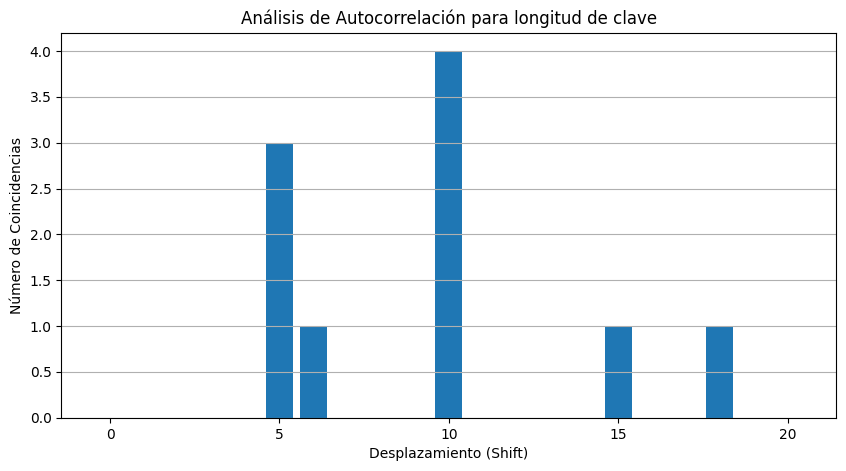

In [24]:
import matplotlib.pyplot as plt

MAX_TEXT_LENGTH = 50
print(
    f"Texto cifrado: {cipher[:MAX_TEXT_LENGTH]}{'...' if len(cipher) > MAX_TEXT_LENGTH else ''}"
)
result = autocorrelacion(cipher)

print("Desplazamiento | Coincidencias")
print("---------------|--------------")
for s, hits in enumerate(result):
    if s > 0:
        print(f"{s:13} | {hits}")


fig = plt.figure(figsize=(10, 5))
plt.bar(range(len(result)), result)
plt.xlabel("Desplazamiento (Shift)")
plt.ylabel("Número de Coincidencias")
plt.title("Análisis de Autocorrelación para longitud de clave")
plt.grid(True, axis="y")
plt.show()

Podemos ver como para un texto cifrado con una clave de longitud 5, se observa un pico tanto en el desplazamiento 5 como en sus múltiplos (10, 15, etc.), tal y como se esperaba.

#### Kaisiski

Por otra parte, el método de Kasiski es una técnica utilizada para determinar la longitud de la clave en un cifrado Vigenère. Consiste en buscar repeticiones de secuencias de letras en el texto cifrado y medir la distancia entre estas repeticiones. La idea es que si una secuencia se repite, es probable que haya sido cifrada con la misma parte de la clave, lo que sugiere que la longitud de la clave es un divisor común de las distancias entre las repeticiones.

In [25]:
from collections import defaultdict

def repeated_sequences(text: str, n: int = 3) -> dict[str, list[int]]:
    """Busca secuencias repetidas de longitud n en el texto y devuelve un diccionario 
    con las secuencias y sus posiciones.

    Args:
        text (str): El texto en el que buscar las secuencias repetidas.
        n (int, optional): La longitud de las secuencias a buscar. Defaults to 3.

    Returns:
        dict[str, list[int]]: Un diccionario con las secuencias repetidas como claves y 
        sus posiciones como valores.
    """
    seqs: dict[str, list[int]] = defaultdict(list)
    for i in range(len(text) - n):
        seq = text[i : i + n]
        seqs[seq].append(i)
    return {k: v for k, v in seqs.items() if len(v) > 1}

Con este método, podemos identificar secuencias de letras que se repiten en el texto cifrado y calcular las distancias entre ellas.

In [26]:
cipher = "LXFOPVEFRNHRLXFOP"
repeated_sequences(cipher, 3)

{'LXF': [0, 12], 'XFO': [1, 13]}

Ahora necesitamos analizar estas distancias para encontrar los divisores comunes, lo que nos dará una estimación de la longitud de la clave.

In [27]:
def kasiski_get_candidates(text: str, seq_len: int = 3) -> list[tuple[int, int]]:
    """Devuelve una lista de posibles longitudes de clave ordenadas por probabilidad.
    Ej: [(4, 15), (2, 10)] -> Longitud 4 apareció 15 veces como factor.


    Args:
        text (str): El texto cifrado del que se quieren obtener las posibles longitudes de clave.
        seq_len (int, optional): La longitud de las secuencias repetidas a buscar. Defaults to 3.

    Returns:
        list[tuple[int, int]]: Una lista de tuplas (longitud, frecuencia) ordenadas por 
        frecuencia descendente.
    """
    seqs = repeated_sequences(text, seq_len)

    distances = []
    for positions in seqs.values():
        for i in range(len(positions) - 1):
            distances.append(positions[i + 1] - positions[i])

    if not distances:
        raise ValueError("No se encontraron secuencias repetidas en el texto.")

    factor_counts = defaultdict(int)
    for d in distances:
        for k in range(2, d + 1):
            if d % k == 0:
                factor_counts[k] += 1

    return sorted(factor_counts.items(), key=lambda x: x[1], reverse=True)

Probamos el funcionamiento del método con un mensaje cifrado de ejemplo.

In [28]:
# Probamos la función sintetizada
kasiski_get_candidates(cipher, 3)

[(2, 2), (3, 2), (4, 2), (6, 2), (12, 2)]

Sin embargo, como podemos ver, esto nos da una gran cantidad de posibles longitudes de clave, cuanto más largo sea el mensaje cifrado, más repeticiones encontraremos, lo que hace que el análisis de los resultados sea más complicado. Por ello, este método se combina con el índice de coincidencia, que veremos a continuación.

##### Índice de Coincidencia (IC)

Una de las técnicas más comunes para determinar la longitud de la clave en un cifrado Vigenère es el Índice de Coincidencia (IC). El IC mide la probabilidad de que dos letras seleccionadas al azar del texto cifrado sean iguales aplicando la fórmula de Friedman. Para un texto en español, el IC típico es alrededor de 0.065, mientras que para un texto cifrado con una clave larga y aleatoria, el IC se acercará a 0.038.

In [29]:
def index_of_coincidence(text: str) -> float:
    """Calcula el Índice de Coincidencia (IC) de un texto dado.

    Args:
        text (str): El texto para el cual se desea calcular el IC.

    Returns:
        float: El Índice de Coincidencia del texto, que es una medida de la probabilidad
        de que dos letras seleccionadas al azar sean iguales.
    """
    counts = Counter(c for c in text.upper() if c.isalpha())
    N = sum(counts.values())
    if N <= 1:
        return 0.0
    numerator = sum(f * (f - 1) for f in counts.values())
    return numerator / (N * (N - 1))

Podemos probar como para un texto en español, el IC se acerca a 0.065, mientras que para un texto cifrado con una clave larga, el IC se acerca a 0.038.

In [30]:
cipher = vigenere_encrypt(plaintext, "CLAVE")
print(f"Índice de Coincidencia del texto original: {index_of_coincidence(plaintext)}")
print(f"Índice de Coincidencia del texto cifrado: {index_of_coincidence(cipher)}")

Índice de Coincidencia del texto original: 0.07072876908576561
Índice de Coincidencia del texto cifrado: 0.0429762977281102


Ahora podemos juntar ambos métodos para obtener una mejor estimación de la longitud de la clave. Primero, utilizamos el método de Kasiski para identificar posibles longitudes de clave, y luego calculamos el IC para cada una de estas longitudes para determinar cuál es la más probable.

In [31]:
def vigenere_key_length_attack(cipher: str):
    """
    Realiza un ataque de análisis de frecuencia al cifrado Vigenère para intentar 
    determinar la longitud de la clave.
    
    Args:
        cipher (str): El texto cifrado que se desea analizar.
    Returns:
        int: La longitud de clave más probable según el análisis.
    """
    candidates = kasiski_get_candidates(cipher)
    top_candidates = [c[0] for c in candidates[:10]]
    # print(f"Kasiski: {top_candidates}")
    THRESHOLD = 0.065
    best_len = 0
    best_ic = 0

    results = {}

    for length in top_candidates:
        # Verificamos el IC para cada longitud candidata dividiendo el texto en subsecuencias
        ics = []
        for i in range(length):
            subseq = cipher[i::length]
            ics.append(index_of_coincidence(subseq))
        avg_ic = sum(ics) / len(ics)
        
        results[length] = avg_ic
        # print(f"Longitud {length}: IC Promedio = {avg_ic:.4f}")
        if avg_ic > THRESHOLD:
            return length # No queremos múltiplos de la longitud real
        
        if avg_ic > best_ic:
            best_ic = avg_ic
            best_len = length

    # print(f"\nLonguitud clave: {best_len} (IC: {best_ic:.4f})")
    return best_len
    

Probamos a estimar la longitud de la clave de nuestro mensaje cifrado. Será necesario limpiar el texto cifrado para eliminar espacios, signos de puntuación y otros caracteres no alfabéticos, ya que en el cifrado de Vigenère implementado solo se consideran las letras del alfabeto. Por lo que, no hacerlo podría afectar a los resultados estadísticos del análisis.

In [32]:
clean_cipher = "".join(c for c in cipher.upper() if c.isalpha())
if not clean_cipher:
    raise ValueError("El texto cifrado no contiene caracteres alfabéticos.")

key_length = vigenere_key_length_attack(clean_cipher)
print(f"Longitud de clave estimada: {key_length}")

Longitud de clave estimada: 5


Finalmente, una vez que tenemos una estimación de la longitud de la clave, podemos dividir el texto cifrado en grupos de letras correspondientes a cada letra de la clave y realizar un análisis de frecuencias en cada grupo para intentar deducir la letra de la clave correspondiente. Esto nos permitirá recuperar la clave completa y descifrar el mensaje original. 

Para ello, podemos usar la función `cesar_get_shift` definida anteriormente para determinar el desplazamiento de cada letra de la clave basándonos en que la letra más frecuente en cada grupo probablemente corresponda a la letra 'E' del alfabeto español. 

In [ ]:
def vigenere_attack(
    cipher: str
) -> str:
    """
      This function performs an attack on a Vigenère cipher by first determining the key
      length using the Kasiski examination, and then performing a frequency analysis
      attack on each sub-cipher to determine the most likely key.

    Args:
        cipher (str): The cipher text to attack
        
    Returns:
        str: The estimated key
    """
    # Tal y como definimos la función vignere solo procesa caracteres alfabéticos, por 
    # lo que limpiamos el texto cifrado para quedarnos solo con las letras y 
    # convertirlas a mayúsculas. Esto nos asegurará que el análisis de frecuencias se
    # realice correctamente.
    clean_cipher = "".join(c for c in cipher.upper() if c.isalpha())
    if not clean_cipher:
        raise ValueError("El texto cifrado no contiene caracteres alfabéticos.")
    
    key_length = vigenere_key_length_attack(clean_cipher)
    key: str = ""
    for i in range(key_length):
        sub_cipher: str = "".join(clean_cipher[j] for j in range(i, len(clean_cipher), key_length))
        key += chr(cesar_get_shift(sub_cipher) + ord("A"))

    return key

In [34]:
MAX_TEXT_LENGTH = 50
print(
    f"Texto cifrado: {cipher[:MAX_TEXT_LENGTH]}{'...' if len(cipher) > MAX_TEXT_LENGTH else ''}"
)
key = vigenere_attack(cipher)
print(f"Clave encontrada: {key}")
decrypted_text = vigenere_decrypt(cipher, key)
print(
    f"Texto descifrado: {decrypted_text[:MAX_TEXT_LENGTH]}{'...' if len(decrypted_text) > MAX_TEXT_LENGTH else ''}"
)

Texto cifrado: ELPFXWWO D
UWP TMEVL DZ PC NOIHKNILR A PJZVETCDS F...
Clave encontrada: CLAVE
Texto descifrado: CAPKTULO I
QUE TRATA DE LA CONDICIQN Y EJERCICIO D...


# 2. Cifrados Modernos

A continuación, implementaremos ataques a cifrados modernos, como el AES en modo CBC y el ataque por nonce reutilizado en cifrados de flujo. Estos ataques aprovechan vulnerabilidades específicas en la implementación de los cifrados modernos para recuperar información sin necesidad de conocer la clave de cifrado.

## AES-CBC

### Implementación del Oráculo de Padding

En esta sección, implementaremos un ataque de padding oracle simulado en el modo de cifrado AES en CBC. Este tipo de ataque aprovecha la información que se puede obtener al intentar descifrar un mensaje con un padding incorrecto, lo que permite a un atacante recuperar el mensaje original sin conocer la clave de cifrado.

In [35]:
from Crypto.Cipher import AES
from Crypto.Util.Padding import unpad


class PaddingOracle:
    def __init__(self, key: bytes):
        self.__key = key
        self.block_size = AES.block_size

    def check_padding(self, ciphertext: bytes, iv: bytes) -> bool:
        """
        Simula un servidor que descifra y solo indica si el padding es válido.
        VULNERABILIDAD: Revelar si el padding falló permite reconstruir el mensaje.
        Args:
            ciphertext (bytes): El bloque cifrado que se desea verificar.
            iv (bytes): El vector de inicialización utilizado para el cifrado.
        Returns:
            bool: True si el padding es correcto, False si el padding es incorrecto.
        """
        cipher = AES.new(self.__key, AES.MODE_CBC, iv=iv)
        decrypted_data = cipher.decrypt(ciphertext)

        try:
            # Si el padding es correcto, unpad no lanza excepción
            unpad(decrypted_data, self.block_size)
            return True
        except ValueError:
            # Padding incorrecto
            return False

En este caso el oráculo solo nos dirá si el padding es correcto o no, lo que nos permitirá deducir información sobre el mensaje cifrado y eventualmente recuperar el mensaje original.

### Ataque a un bloque específico

In [36]:
def attack_single_block(c_target: bytes, c_prev: bytes, oracle: PaddingOracle) -> bytes:
    """
    Ataca un bloque específico (c_target) usando el bloque anterior (c_prev).
    Args:
        c_target (bytes): El bloque cifrado que se desea atacar.
        c_prev (bytes): El bloque cifrado anterior a c_target (o IV si es el primer bloque).
        oracle (PaddingOracle): La instancia del oracle de padding que se utilizará
    Returns:
        bytes: El bloque de texto plano correspondiente a c_target.
    """
    block_size = 16
    intermediate = [0] * block_size
    plaintext = [0] * block_size

    # Atacamos desde el último byte (índice 15) hasta el primero (0)
    for i in range(block_size - 1, -1, -1):
        expected_padding = block_size - i

        # Preparamos un bloque anterior falso (modified_prev)
        # Los bytes ya adivinados se ajustan para el nuevo padding
        prefix = [0] * i
        suffix = []
        for j in range(i + 1, block_size):
            suffix.append(intermediate[j] ^ expected_padding)
        
        found: bool = False
        for val in range(256):
            test_iv_bytes = bytes(prefix + [val] + suffix)
            
            if oracle.check_padding(c_target, iv=test_iv_bytes):
                intermediate[i] = val ^ expected_padding
                plaintext[i] = intermediate[i] ^ c_prev[i]
                found = True
                break
        
        if not found:
            print(f"Error: No se encontró byte válido para la posición {i}")

    return bytes(plaintext)

Finalmente, implementaremos el ataque de padding oracle para recuperar un bloque específico del mensaje cifrado. Este ataque se basa en modificar el bloque anterior al bloque objetivo y observar las respuestas del oráculo para deducir el contenido del bloque objetivo.

In [37]:
from Crypto.Cipher import AES
from Crypto.Util.Padding import pad
from Crypto.Random import get_random_bytes

# 1. Setup
KEY = get_random_bytes(16)
IV = get_random_bytes(16)
# Usamos un mensaje largo para tener 2 bloques
mensaje_secreto = b"ESTE ES UN MENSAJE SECRETO"

cipher = AES.new(KEY, AES.MODE_CBC, iv=IV)
ciphertext_original = cipher.encrypt(pad(mensaje_secreto, AES.block_size))
oracle = PaddingOracle(KEY)

print(f"Mensaje cifrado (hex): {ciphertext_original.hex()}")
print(f"Longitud cifrado: {len(ciphertext_original)} bytes")

# 2. Dividir en bloques de 16 bytes
blocks = [ciphertext_original[i:i+16] for i in range(0, len(ciphertext_original), 16)]
# Insertamos el IV al principio porque sirve como "bloque previo" para el primer bloque cifrado
blocks.insert(0, IV) 

recovered_message = b""

# 3. Bucle Principal: Atacar bloque a bloque
# Empezamos desde el bloque 1 (el cifrado real) usando el bloque anterior como IV
for i in range(1, len(blocks)):
    c_target = blocks[i]      # El bloque que queremos descifrar
    c_prev = blocks[i-1]      # El bloque anterior (actúa como IV en CBC)
    
    print(f"Atacando bloque {i}...")
    recovered_block = attack_single_block(c_target, c_prev, oracle)
    print(f" -> Bloque descifrado: {recovered_block}")
    recovered_message += recovered_block

# 4. Resultado final (Quitamos el padding manualmente para ver que es perfecto)
print("\n--- ATAQUE COMPLETADO ---")
print(f"Mensaje recuperado (con padding): {recovered_message}")
try:
    print(f"Mensaje final: {unpad(recovered_message, 16).decode()}")
except:
    print("Error al quitar padding final (algo falló en el ataque)")

Mensaje cifrado (hex): b67b118ca4bb1527352e35b7a30b6097f624c6f555356e1780136fc65bc755ac
Longitud cifrado: 32 bytes
Atacando bloque 1...
 -> Bloque descifrado: b'ESTE ES UN MENSA'
Atacando bloque 2...
 -> Bloque descifrado: b'JE SECRETO\x06\x06\x06\x06\x06\x06'

--- ATAQUE COMPLETADO ---
Mensaje recuperado (con padding): b'ESTE ES UN MENSAJE SECRETO\x06\x06\x06\x06\x06\x06'
Mensaje final: ESTE ES UN MENSAJE SECRETO


## AES-GCM

In [38]:
from Crypto.Cipher import AES
from Crypto.Random import get_random_bytes

# --- 1. ESCENARIO (LA VÍCTIMA) ---
# La víctima usa AES-GCM, que es muy seguro...
# PERO comete el error fatal de "hardcodear" el nonce.

KEY = get_random_bytes(32)  # Clave segura de 256 bits
FIXED_NONCE = b"\x00" * 12  # ¡ERROR CRÍTICO! Nonce fijo (o reutilizado)


def victim_encrypt(msg: str):
    cipher = AES.new(KEY, AES.MODE_GCM, nonce=FIXED_NONCE)
    ciphertext, tag = cipher.encrypt_and_digest(msg.encode())
    return ciphertext


# La víctima envía dos mensajes distintos
msg_real_1 = "Transferir 1000$ a Alice"
msg_real_2 = "Transferir 9999$ a Bob!!"

c1 = victim_encrypt(msg_real_1)
c2 = victim_encrypt(msg_real_2)

print(f"Cifrado 1 (Hex): {c1.hex()}")
print(f"Cifrado 2 (Hex): {c2.hex()}")
print("-" * 40)

# --- 2. EL ATACANTE (TÚ) ---
# El atacante NO tiene la clave (KEY). Solo ve c1 y c2.
# Pero sabe que se reusó el nonce.


def xor_bytes(a: bytes, b: bytes) -> bytes:
    """Realiza XOR byte a byte entre dos cadenas de bytes"""
    return bytes(x ^ y for x, y in zip(a, b))


# PASO A: El atacante hace XOR de los dos criptogramas
# C1 ^ C2 = (P1 ^ K) ^ (P2 ^ K) = P1 ^ P2
xor_plaintexts = xor_bytes(c1, c2)

print(f"XOR de Textos Planos (P1 ^ P2): {xor_plaintexts.hex()}")

# PASO B: Recuperación de información (Known Plaintext Attack)
# Imaginemos que el atacante sospecha que el primer mensaje es sobre "Alice".
# Si adivina una parte de P1, ¡automáticamente revela P2!

guess = "Alice"  # Atacante prueba una palabra
# Truco: Movemos la palabra 'guess' a lo largo del XOR para ver qué aparece
print("\n--- VISUALIZACIÓN DEL ATAQUE ---")
print(f"Suposición del atacante: '{guess}'")

# Convertimos la suposición a bytes
guess_bytes = guess.encode()

# Hacemos (P1 ^ P2) ^ "Alice"
# Si "Alice" es parte de P1, el resultado será la parte correspondiente de P2.
revealed = xor_bytes(xor_plaintexts[-5:], guess_bytes)
# Nota: Uso [-5:] porque "Alice" está al final del msg_real_1.
# En un ataque real probarías todas las posiciones (Crib Dragging).

print(f"Texto revelado mágicamente: '{revealed.decode()}'")

Cifrado 1 (Hex): dad662320e0d444b23a62bcdf3713a0c5057742882fab911
Cifrado 2 (Hex): dad662320e0d444b23a62bc5fa78330c5057742b81f1fb55
----------------------------------------
XOR de Textos Planos (P1 ^ P2): 0000000000000000000000080909090000000003030b4244

--- VISUALIZACIÓN DEL ATAQUE ---
Suposición del atacante: 'Alice'
Texto revelado mágicamente: 'Bob!!'


In [39]:
def crib_drag_visual(xor_data: bytes, crib: str):
    """
    Arrastra una palabra probable (crib) sobre el XOR de los textos
    para ver si revela algo legible en el otro mensaje.
    """
    crib_bytes = crib.encode()
    print(f"Arrastrando la palabra probable: '{crib}'\n")

    for i in range(len(xor_data) - len(crib_bytes) + 1):
        # Extraemos el trozo del XOR en la posición actual
        chunk = xor_data[i : i + len(crib_bytes)]

        # Aplicamos la suposición: (P1^P2) ^ Crib
        try:
            potential_text = xor_bytes(chunk, crib_bytes).decode()
        except:
            potential_text = "?????"  # Caracteres no imprimibles

        # Visualización tipo Matrix
        padding = " " * i
        print(f"Pos {i:02}: {padding} -> Revela: '{potential_text}'")


# Ejecución
crib_drag_visual(xor_plaintexts, "Transferir")

Arrastrando la palabra probable: 'Transferir'

Pos 00:  -> Revela: 'Transferir'
Pos 01:   -> Revela: 'Transferir'
Pos 02:    -> Revela: 'Transferiz'
Pos 03:     -> Revela: 'Transfera{'
Pos 04:      -> Revela: 'Transfez`{'
Pos 05:       -> Revela: 'Transfm{`{'
Pos 06:        -> Revela: 'Transnl{`r'
Pos 07:         -> Revela: 'Tran{ol{ir'
Pos 08:          -> Revela: 'Trafzolrir'
Pos 09:           -> Revela: 'Trigzoerir'
Pos 10:            -> Revela: 'Tzhgzferiq'
Pos 11:             -> Revela: '\{hgsferjq'
Pos 12:              -> Revela: ']{hnsfeqjy'
Pos 13:               -> Revela: ']{ansffqb0'
Pos 14:                -> Revela: ']ransefy+6'
